
# Beer PCA → (비상관 PC score) → 관능평가 회귀 실험 (Excel 원본 사용)

## 실험 목적(요약)
- **화학 feature(231개)** 들 사이의 **상관/공분산 구조**가 존재하는 상태에서 선형회귀를 바로 적용하면  
  \((X^\top X)^{-1}\) 관련 수치적 불안정/계수 불안정(다중공선성)이 발생할 수 있습니다.
- 그래서 **train 데이터로 PCA 축(고유벡터 기저)을 학습**해 **PC score들끼리 공분산이 0(비상관)**이 되도록 만들고,
- 그 PC score로 관능평가(50개)를 예측하는 회귀모델(PCR)을 학습/평가합니다.
- 또한 train에서 학습된 **스케일러+PCA 축을 저장**하여, 이후 동일한 축으로 계속 변환(transform)할 수 있게 합니다.

---

## PCA를 “선형대수 + 확률통계”로만 정의하기 (최소 핵심)

### 1) 공분산 행렬
화학 feature 벡터를 확률변수 \(X\in\mathbb{R}^p\)라 두면,
\[
\Sigma = \mathrm{Cov}(X)=\mathbb{E}[(X-\mu)(X-\mu)^\top]
\]
- 비대각 원소가 0이 아니면 feature들이 **함께 변한다(상관/공분산 존재)**고 말할 수 있습니다.

### 2) 대칭행렬의 직교대각화(스펙트럴 정리)
\(\Sigma\)는 대칭행렬이므로,
\[
\Sigma = V\Lambda V^\top
\]
- \(V\)의 열벡터 = **고유벡터(새 축, PC 축)**
- \(\Lambda\) 대각 원소 = **고유값(PC별 분산)**

### 3) 고유벡터 기저로 좌표변환 → 공분산이 대각행렬
센터링 후 새 좌표를
\[
Z = V^\top (X-\mu)
\]
로 정의하면
\[
\mathrm{Cov}(Z)=V^\top \Sigma V=\Lambda
\]
즉 **PC score들끼리 공분산이 0**(비상관)입니다.

> 주의: 비상관(공분산 0)이지, 확률적 독립까지 보장하진 않습니다.

---

## 이 노트북이 하는 일
1. Excel에서 화학/관능 시트를 읽고(250개 샘플),
2. 70/30(175/75) **stratified split**(style 기준)로 train/test를 만들고,
3. **train만**으로 결측처리+스케일링+PCA fit,
4. 변환된 PC score에서 **비상관 확인**,
5. PCR(Linear/Ridge/ElasticNet) 학습/평가,
6. 결과(artifacts/metrics/predictions/plots)를 지정 output 폴더에 **현재시간 파일명**으로 저장합니다.


In [1]:

import os
import json
import datetime as dt
from typing import Tuple, Optional, List, Dict, Any

import numpy as np
import pandas as pd

import joblib

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, make_scorer


In [2]:

# =========================================================
# 0) 경로/실험 설정 (여기만 수정하면 됨)                       # ★ 중요
# =========================================================

# ---------- 데이터 경로(서버 기본 경로) ----------
DATA_XLSX_PATH = r"/home/a202192020/맥주데이터실험/data/Supplemental Files and Figure source files.xlsx"

# (로컬/노트북 환경에서 실행 시) 업로드 파일 fallback
FALLBACK_XLSX_PATH = r"/mnt/data/Supplemental Files and Figure source files.xlsx"

# ---------- Excel 시트 선택 ----------
CHEM_SHEET   = "Supplementary File S1"   # 250 x (3 meta + 231 chemical)         # ★ 중요
SENS_SHEET   = "Supplementary File S4"   # 250 x (3 meta + 50 sensory)           # ★ 중요

# ---------- 출력 폴더 ----------
OUT_DIR = r"/home/a202192020/맥주데이터실험/pca/0220/beer_pca_excel_pcr_run_output" # ★ 중요

# ---------- split 설정 (175/75) ----------
TEST_SIZE = 0.30
RANDOM_STATE = 42
STRATIFY_COL = "tasting_category_fine"  # style stratify

# ---------- PCA 설정 ----------
STANDARDIZE_BEFORE_PCA = True     # 상관(=표준화된 공분산) 제거 목적이면 True 권장     # ★ 중요
PCA_SVD_SOLVER = "full"           # 결정적/안정적
RANK_TOL = 1e-12

# k 선택 방식
# - "lossless_rank": train에서 정보손실 없이 줄이는 최소 차원(=rank ≤ n-1)
# - "evr_threshold": 누적 설명분산 기준
# - "manual": 직접 k
# - "cv_search": k를 CV로 선택(예측 성능 최적화)
N_COMPONENTS_MODE = "lossless_rank"
EVR_THRESHOLD = 0.99
MANUAL_K = 50

# ---------- 회귀 모델 ----------
MODEL_NAME = "ridge"   # "linreg" | "ridge" | "elasticnet"
RIDGE_ALPHA = 1.0
ELASTICNET_ALPHA = 0.01
ELASTICNET_L1_RATIO = 0.2

# ---------- CV(선택) ----------
N_SPLITS = 5

# ---------- 현재시간 RUN TAG ----------
RUN_TAG = dt.datetime.now().strftime("%Y%m%d_%H%M%S")

# ---------- 결과 파일명(현재시간 포함) ----------
PCA_ARTIFACT_PATH   = os.path.join(OUT_DIR, f"pca_artifact_{RUN_TAG}.joblib")
MODEL_ARTIFACT_PATH = os.path.join(OUT_DIR, f"reg_model_{RUN_TAG}.joblib")
METRICS_CSV_PATH    = os.path.join(OUT_DIR, f"metrics_{RUN_TAG}.csv")
PRED_CSV_PATH       = os.path.join(OUT_DIR, f"test_pred_{RUN_TAG}.csv")
EVR_PNG_PATH        = os.path.join(OUT_DIR, f"evr_{RUN_TAG}.png")
CUMEVR_PNG_PATH     = os.path.join(OUT_DIR, f"cumevr_{RUN_TAG}.png")

os.makedirs(OUT_DIR, exist_ok=True)

print("RUN_TAG:", RUN_TAG)
print("OUT_DIR:", OUT_DIR)


RUN_TAG: 20260220_180647
OUT_DIR: /home/a202192020/맥주데이터실험/pca/0220/beer_pca_excel_pcr_run_output


In [3]:

# =========================================================
# 1) Excel 로드 + 시트 확인
# =========================================================

# (1) 경로 fallback
if not os.path.exists(DATA_XLSX_PATH):
    if os.path.exists(FALLBACK_XLSX_PATH):
        print("⚠️ 서버 경로에 파일이 없어 fallback 경로를 사용합니다:", FALLBACK_XLSX_PATH)
        DATA_XLSX_PATH = FALLBACK_XLSX_PATH
    else:
        raise FileNotFoundError(f"데이터 파일을 찾을 수 없습니다:\n- {DATA_XLSX_PATH}\n- {FALLBACK_XLSX_PATH}")

print("DATA_XLSX_PATH =", DATA_XLSX_PATH)

# (2) 시트 목록
xls = pd.ExcelFile(DATA_XLSX_PATH)
print("Sheets:", xls.sheet_names)

# (3) 화학/관능 로드
chem_df = pd.read_excel(DATA_XLSX_PATH, sheet_name=CHEM_SHEET)
sens_df = pd.read_excel(DATA_XLSX_PATH, sheet_name=SENS_SHEET)

print("chem_df:", chem_df.shape)
print("sens_df:", sens_df.shape)

chem_df.head(2)


DATA_XLSX_PATH = /home/a202192020/맥주데이터실험/data/Supplemental Files and Figure source files.xlsx
Sheets: ['Supplementary File S1', 'Supplementary File S2', 'Supplementary File S3', 'Supplementary File S4', 'Supplementary File S5', 'Supplementary File S6', 'Supplementary File S7', 'Supplementary Table S1', 'Supplementary Table S2', 'Supplementary Table S3', 'Supplementary Table S4', 'Supplementary Table S5', 'Supplementary Table S6', 'Supplementary Table S7', 'Sensory thresholds', 'Sensory names', 'Validation Results 1', 'Validation Results 2', 'Validation Results 3', 'Validation Concentrations', 'Validation Details', 'GBM importance MDI', 'GBM SHAP Values', 'Calibrated chemical dataset', 'Beer Prices', 'Performance of 100 models', '100 models feature importance', 'GBM model on merged dataset', 'GBM model with style informatio']
chem_df: (250, 234)
sens_df: (250, 53)


,beer,beer_id,tasting_category_fine,acetaldehyde,CS2,DES,DMS,ethyl_2.methyl_butyrate,ethyl_acetate,ethyl_decanoate,...,X13.epi.manool.oxide,isopropyl.hexadecanoate,manool,ethyl.octadecanoate,ethyl.pentanoate,X2.ethyl.3.methylpyrazine,esters_sum,aroma_hops_sum,acids_sum,sulfur_sum
0,10,5410228202929,Low/No alcohol,-0.641741,-2.146292,-1.905267,0.046211,-3.19552,-0.599350,-1.975309,...,4.360243,-1.817819,5.721204,4.438951,0.014728,0.054353,-0.532634,3.696586,0.244085,0.166286
1,86,5410783031019,Low/No alcohol,-0.174824,-2.146292,-0.257098,0.347241,-3.19552,-0.507254,-1.755970,...,4.512589,4.323292,5.810501,4.247826,0.023167,0.001400,-0.465401,1.219563,-0.152156,0.098931


In [4]:

# =========================================================
# 2) merge + feature/target 컬럼 자동 추출
# =========================================================

META_COLS = ["beer", "beer_id", "tasting_category_fine"]

# (1) merge (beer_id 기준; meta는 일치한다고 가정)
df = chem_df.merge(
    sens_df,
    on=META_COLS,
    how="inner",
    validate="one_to_one"
)

print("merged df:", df.shape)

# (2) feature/target columns
feature_cols = [c for c in chem_df.columns if c not in META_COLS]
target_cols  = [c for c in sens_df.columns if c not in META_COLS]

print("#features:", len(feature_cols))
print("#targets :", len(target_cols))
print("first 5 features:", feature_cols[:5])
print("first 5 targets :", target_cols[:5])

# sanity
assert len(feature_cols) == 231, f"feature_cols={len(feature_cols)} (231 expected)"
assert len(target_cols)  == 50,  f"target_cols={len(target_cols)} (50 expected)"

df[META_COLS].head(3)


merged df: (250, 284)
#features: 231
#targets : 50
first 5 features: ['acetaldehyde', 'CS2', 'DES', 'DMS', 'ethyl_2.methyl_butyrate']
first 5 targets : ['A_malt_all', 'A_malt_grain', 'A_malt_bread', 'A_malt_cara', 'A_malt_burn']


,beer,beer_id,tasting_category_fine
0,10,5410228202929,Low/No alcohol
1,86,5410783031019,Low/No alcohol
2,2,5410228142003,Low/No alcohol


In [5]:

# =========================================================
# 3) train/test split (175/75, stratified by style)
# =========================================================

stratify_vec = df[STRATIFY_COL] if STRATIFY_COL in df.columns else None

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=stratify_vec,
)

print("train_df:", train_df.shape, " / test_df:", test_df.shape)
print("train n:", len(train_df), "test n:", len(test_df))

# 기대: 175/75 (250 기준)
train_df[STRATIFY_COL].value_counts().head(10)


train_df: (175, 284)  / test_df: (75, 284)
train n: 175 test n: 75


tasting_category_fine
Blond           22
Tripel          20
Strong ale      13
Hoppy           12
Stout/Porter     9
Brown            8
Amber            8
Lambic           8
Pils/Lager       8
Wheat            8
Name: count, dtype: int64

In [6]:

# =========================================================
# 4) X/y 구성 + 결측치 처리(평균 대체; train 기준)
# =========================================================

X_train = train_df[feature_cols].copy()
y_train = train_df[target_cols].copy()

X_test  = test_df[feature_cols].copy()
y_test  = test_df[target_cols].copy()

# ---- 결측 확인 ----
print("missing(X_train):", int(X_train.isna().sum().sum()))
print("missing(X_test) :", int(X_test.isna().sum().sum()))

# ---- train 평균으로 대체 ----
impute_means = X_train.mean(axis=0)
X_train = X_train.fillna(impute_means)
X_test  = X_test.fillna(impute_means)

print("after impute - missing(X_train):", int(X_train.isna().sum().sum()))


missing(X_train): 51
missing(X_test) : 22
after impute - missing(X_train): 0


In [7]:

# =========================================================
# 5) (train만) 스케일링 + PCA fit
# =========================================================

# (1) 표준화: with_std=True면 '상관(=표준화된 공분산)' 기준 PCA와 동일해짐
scaler = StandardScaler(with_mean=True, with_std=STANDARDIZE_BEFORE_PCA)
Xtr_s = scaler.fit_transform(X_train)
Xte_s = scaler.transform(X_test)

# (2) full PCA로 고유값(=설명분산) 전체 확인
pca_full = PCA(n_components=None, svd_solver=PCA_SVD_SOLVER)
pca_full.fit(Xtr_s)

explained = pca_full.explained_variance_
explained_ratio = pca_full.explained_variance_ratio_
cum_ratio = np.cumsum(explained_ratio)

k_lossless = int(np.sum(explained > RANK_TOL))
k_evr = int(np.searchsorted(cum_ratio, EVR_THRESHOLD) + 1)

print("pca_full n_components:", pca_full.n_components_)
print(f"k_lossless (rank, tol={RANK_TOL}):", k_lossless)
print(f"k_evr (cum EVR>={EVR_THRESHOLD}):", k_evr)

# (3) 최종 k 결정
if N_COMPONENTS_MODE == "lossless_rank":
    k = k_lossless
elif N_COMPONENTS_MODE == "evr_threshold":
    k = k_evr
elif N_COMPONENTS_MODE == "manual":
    k = MANUAL_K
elif N_COMPONENTS_MODE == "cv_search":
    k = None
else:
    raise ValueError("N_COMPONENTS_MODE must be one of lossless_rank/evr_threshold/manual/cv_search")

print("Selected k:", k)


pca_full n_components: 175
k_lossless (rank, tol=1e-12): 174
k_evr (cum EVR>=0.99): 127
Selected k: 174


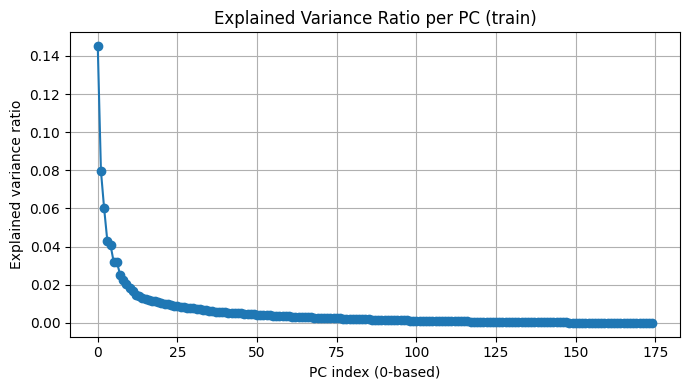

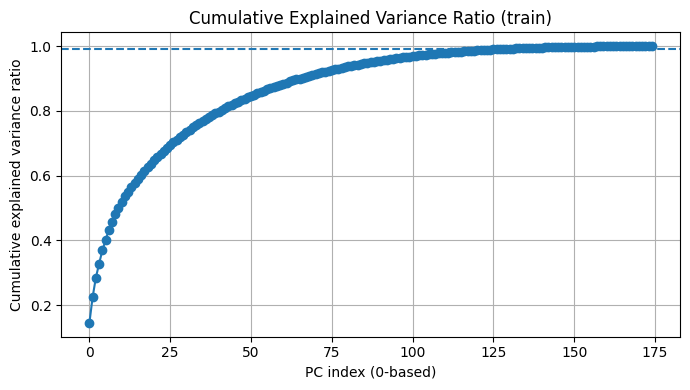

✅ saved: /home/a202192020/맥주데이터실험/pca/0220/beer_pca_excel_pcr_run_output/evr_20260220_180647.png
✅ saved: /home/a202192020/맥주데이터실험/pca/0220/beer_pca_excel_pcr_run_output/cumevr_20260220_180647.png


In [8]:

# =========================================================
# 6) EVR plot 저장
# =========================================================

plt.figure(figsize=(7,4))
plt.plot(explained_ratio, marker="o")
plt.title("Explained Variance Ratio per PC (train)")
plt.xlabel("PC index (0-based)")
plt.ylabel("Explained variance ratio")
plt.grid(True)
plt.tight_layout()
plt.savefig(EVR_PNG_PATH, dpi=150)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(cum_ratio, marker="o")
plt.axhline(EVR_THRESHOLD, linestyle="--")
plt.title("Cumulative Explained Variance Ratio (train)")
plt.xlabel("PC index (0-based)")
plt.ylabel("Cumulative explained variance ratio")
plt.grid(True)
plt.tight_layout()
plt.savefig(CUMEVR_PNG_PATH, dpi=150)
plt.show()

print("✅ saved:", EVR_PNG_PATH)
print("✅ saved:", CUMEVR_PNG_PATH)


In [9]:

# =========================================================
# 7) 선택한 k로 PCA 변환 + 비상관(공분산 비대각≈0) 확인
# =========================================================

def max_abs_offdiag_cov(Z: np.ndarray) -> float:
    C = np.cov(Z, rowvar=False, ddof=1)
    off = C - np.diag(np.diag(C))
    return float(np.max(np.abs(off)))

if k is not None:
    pca = PCA(n_components=k, svd_solver=PCA_SVD_SOLVER)
    Z_train = pca.fit_transform(Xtr_s)
    Z_test  = pca.transform(Xte_s)

    print("Z_train:", Z_train.shape, "Z_test:", Z_test.shape)
    print("max |off-diagonal covariance| (Z_train):", max_abs_offdiag_cov(Z_train))
else:
    pca = None
    Z_train, Z_test = None, None
    print("cv_search 모드: 다음 셀에서 k를 찾은 뒤 변환합니다.")


Z_train: (175, 174) Z_test: (75, 174)
max |off-diagonal covariance| (Z_train): 8.742788483900566e-15


In [10]:

# =========================================================
# 8) (선택) 재구성 오차: train에서 lossless인지 확인
# =========================================================

def reconstruction_rmse(X_true: np.ndarray, X_hat: np.ndarray) -> float:
    return float(np.sqrt(np.mean((X_true - X_hat) ** 2)))

if k is not None:
    Xtr_s_hat = pca.inverse_transform(Z_train)
    rmse_scaled = reconstruction_rmse(Xtr_s, Xtr_s_hat)

    Xtr_hat = scaler.inverse_transform(Xtr_s_hat)
    rmse_raw = reconstruction_rmse(X_train.values, Xtr_hat)

    print(f"Reconstruction RMSE (scaled): {rmse_scaled:.6e}")
    print(f"Reconstruction RMSE (raw):    {rmse_raw:.6e}")
    print(f"(k={k}) vs (k_lossless={k_lossless})")


Reconstruction RMSE (scaled): 2.114907e-15
Reconstruction RMSE (raw):    2.086243e-13
(k=174) vs (k_lossless=174)


In [11]:

# =========================================================
# 9) PCA 축(스케일러+PCA) 저장 (계속 재사용 가능)
# =========================================================

if k is not None:
    artifact = {
        "run_tag": RUN_TAG,
        "data_xlsx_path": DATA_XLSX_PATH,
        "chem_sheet": CHEM_SHEET,
        "sens_sheet": SENS_SHEET,
        "meta_cols": META_COLS,

        "feature_cols": feature_cols,
        "target_cols": target_cols,

        "standardize_before_pca": STANDARDIZE_BEFORE_PCA,
        "impute_means": impute_means,

        "scaler": scaler,
        "pca": pca,
        "k": k,

        "explained_variance": explained[:pca.n_components_],
        "explained_variance_ratio": explained_ratio[:pca.n_components_],
    }
    joblib.dump(artifact, PCA_ARTIFACT_PATH)
    print("✅ saved:", PCA_ARTIFACT_PATH)
else:
    print("cv_search 모드: k 확정 후 저장하세요.")


✅ saved: /home/a202192020/맥주데이터실험/pca/0220/beer_pca_excel_pcr_run_output/pca_artifact_20260220_180647.joblib


In [12]:

# =========================================================
# 10) 회귀 모델 학습/평가: Baseline vs PCR
# =========================================================

def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred, multioutput="uniform_average")))

def r2(y_true, y_pred) -> float:
    return float(r2_score(y_true, y_pred, multioutput="uniform_average"))

def per_target_metrics(y_true_df: pd.DataFrame, y_pred: np.ndarray, prefix: str="") -> pd.DataFrame:
    rows = []
    for i, col in enumerate(y_true_df.columns):
        yt = y_true_df[col].values
        yp = y_pred[:, i]
        rows.append({
            "target": col,
            f"{prefix}RMSE": float(np.sqrt(mean_squared_error(yt, yp))),
            f"{prefix}R2": float(r2_score(yt, yp)),
        })
    return pd.DataFrame(rows)

def make_model(name: str):
    name = name.lower()
    if name == "linreg":
        return LinearRegression()
    if name == "ridge":
        return Ridge(alpha=RIDGE_ALPHA, random_state=RANDOM_STATE)
    if name == "elasticnet":
        return ElasticNet(alpha=ELASTICNET_ALPHA, l1_ratio=ELASTICNET_L1_RATIO, random_state=RANDOM_STATE)
    raise ValueError("MODEL_NAME must be one of: linreg, ridge, elasticnet")

# ---------- Baseline: 원본 feature로 회귀(표준화만) ----------
baseline_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("model", make_model(MODEL_NAME)),
])
baseline_pipe.fit(X_train, y_train)

pred_tr_base = baseline_pipe.predict(X_train)
pred_te_base = baseline_pipe.predict(X_test)

print("[Baseline] Train RMSE:", rmse(y_train, pred_tr_base), "R2:", r2(y_train, pred_tr_base))
print("[Baseline] Test  RMSE:", rmse(y_test, pred_te_base), "R2:", r2(y_test, pred_te_base))

# ---------- PCR: PCA score로 회귀 ----------
if k is not None:
    pcr_pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=STANDARDIZE_BEFORE_PCA)),
        ("pca", PCA(n_components=k, svd_solver=PCA_SVD_SOLVER)),
        ("model", make_model(MODEL_NAME)),
    ])
    pcr_pipe.fit(X_train, y_train)

    pred_tr_pcr = pcr_pipe.predict(X_train)
    pred_te_pcr = pcr_pipe.predict(X_test)

    print(f"\n[PCR k={k}] Train RMSE:", rmse(y_train, pred_tr_pcr), "R2:", r2(y_train, pred_tr_pcr))
    print(f"[PCR k={k}] Test  RMSE:", rmse(y_test, pred_te_pcr), "R2:", r2(y_test, pred_te_pcr))

    # ----- 결과 저장(요약 + 타깃별) -----
    summary = pd.DataFrame([
        {"run_tag": RUN_TAG, "model": MODEL_NAME, "mode": "baseline_raw",
         "split": "train", "RMSE": rmse(y_train, pred_tr_base), "R2": r2(y_train, pred_tr_base)},
        {"run_tag": RUN_TAG, "model": MODEL_NAME, "mode": "baseline_raw",
         "split": "test",  "RMSE": rmse(y_test, pred_te_base), "R2": r2(y_test, pred_te_base)},
        {"run_tag": RUN_TAG, "model": MODEL_NAME, "mode": f"pcr_k={k}",
         "split": "train", "RMSE": rmse(y_train, pred_tr_pcr), "R2": r2(y_train, pred_tr_pcr)},
        {"run_tag": RUN_TAG, "model": MODEL_NAME, "mode": f"pcr_k={k}",
         "split": "test",  "RMSE": rmse(y_test, pred_te_pcr), "R2": r2(y_test, pred_te_pcr)},
    ])

    per_t_test = per_target_metrics(y_test, pred_te_pcr, prefix="PCR_")
    per_t_test["run_tag"] = RUN_TAG
    per_t_test["mode"] = f"pcr_k={k}"
    per_t_test["split"] = "test"

    metrics_out = pd.concat([summary, per_t_test], axis=0, ignore_index=True)
    metrics_out.to_csv(METRICS_CSV_PATH, index=False)
    print("✅ saved:", METRICS_CSV_PATH)

    # ----- 예측 저장(beer_id 포함) -----
    pred_df = pd.DataFrame(pred_te_pcr, columns=[f"pred_{c}" for c in target_cols])
    out_df = test_df[META_COLS].reset_index(drop=True).join(pred_df)
    out_df.to_csv(PRED_CSV_PATH, index=False)
    print("✅ saved:", PRED_CSV_PATH)

    # ----- 전체 파이프 저장 -----
    joblib.dump(pcr_pipe, MODEL_ARTIFACT_PATH)
    print("✅ saved:", MODEL_ARTIFACT_PATH)

else:
    print("cv_search 모드: 다음 셀에서 best 파이프를 구해 저장합니다.")


[Baseline] Train RMSE: 0.04633309155258738 R2: 0.9925873873211896
[Baseline] Test  RMSE: 0.937135313691394 R2: -2.1003024688652

[PCR k=174] Train RMSE: 0.04633309155258758 R2: 0.9925873873211896
[PCR k=174] Test  RMSE: 0.9371353136913928 R2: -2.1003024688651952
✅ saved: /home/a202192020/맥주데이터실험/pca/0220/beer_pca_excel_pcr_run_output/metrics_20260220_180647.csv
✅ saved: /home/a202192020/맥주데이터실험/pca/0220/beer_pca_excel_pcr_run_output/test_pred_20260220_180647.csv
✅ saved: /home/a202192020/맥주데이터실험/pca/0220/beer_pca_excel_pcr_run_output/reg_model_20260220_180647.joblib


In [13]:

# =========================================================
# 11) (선택) k를 CV로 선택 (예측 성능 기준) + 저장
# =========================================================
# - N_COMPONENTS_MODE='cv_search'일 때만 사용
# - 이 경우 PCA 축은 fold마다 달라질 수 있으니, 최종적으로 best_estimator를 저장해 사용하세요.

if N_COMPONENTS_MODE != "cv_search":
    print("N_COMPONENTS_MODE != 'cv_search' 이므로 스킵합니다.")
else:
    max_k = min(len(train_df)-1, len(feature_cols))  # <= 174 (train=175)
    k_grid = sorted(set([2, 5, 10, 20, 30, 40, 60, 80, 120, max_k]))
    k_grid = [kk for kk in k_grid if 1 <= kk <= max_k]

    param_grid = {"pca__n_components": k_grid}

    if MODEL_NAME.lower() == "ridge":
        param_grid["model__alpha"] = np.logspace(-3, 3, 13).tolist()
    elif MODEL_NAME.lower() == "elasticnet":
        param_grid["model__alpha"] = np.logspace(-4, 1, 10).tolist()
        param_grid["model__l1_ratio"] = [0.1, 0.2, 0.5, 0.8, 0.95]

    cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    def rmse_scorer(y_true, y_pred):
        return -float(np.sqrt(mean_squared_error(y_true, y_pred, multioutput="uniform_average")))

    scorer = make_scorer(rmse_scorer, greater_is_better=True)

    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=STANDARDIZE_BEFORE_PCA)),
        ("pca", PCA(svd_solver=PCA_SVD_SOLVER)),
        ("model", make_model(MODEL_NAME)),
    ])

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scorer,
        cv=cv,
        n_jobs=-1,
        verbose=1,
    )
    gs.fit(X_train, y_train)

    best_pipe = gs.best_estimator_
    print("Best params:", gs.best_params_)
    print("Best CV score (neg RMSE):", gs.best_score_)

    # 저장
    joblib.dump(best_pipe, MODEL_ARTIFACT_PATH)
    print("✅ saved:", MODEL_ARTIFACT_PATH)

    # test 예측 저장
    pred = best_pipe.predict(X_test)
    pred_df = pd.DataFrame(pred, columns=[f"pred_{c}" for c in target_cols])
    out_df = test_df[META_COLS].reset_index(drop=True).join(pred_df)
    out_df.to_csv(PRED_CSV_PATH, index=False)
    print("✅ saved:", PRED_CSV_PATH)


N_COMPONENTS_MODE != 'cv_search' 이므로 스킵합니다.


In [14]:

# =========================================================
# 12) 저장된 PCA artifact를 다시 불러와 transform 하는 예시
# =========================================================

loaded = joblib.load(PCA_ARTIFACT_PATH)

loaded_feature_cols = loaded["feature_cols"]
loaded_means = loaded["impute_means"]
loaded_scaler = loaded["scaler"]
loaded_pca = loaded["pca"]

def pca_transform_new(df_any: pd.DataFrame) -> np.ndarray:
    X = df_any[loaded_feature_cols].copy()
    X = X.fillna(loaded_means)
    Xs = loaded_scaler.transform(X)
    Z = loaded_pca.transform(Xs)
    return Z

Z_check = pca_transform_new(train_df)
print("Z_check shape:", Z_check.shape)


Z_check shape: (175, 174)


validation

In [16]:
# =========================================================
# [VALIDATION] 5-Fold(층화) CV + PCA k 선택 + Ridge alpha 튜닝     # ★ 핵심
# - fold 분할은 tasting_category_fine(스타일) 기준 층화           # ★ 중요
# - scaler/PCA는 각 fold의 train에서만 fit → val에는 transform만  # ★ 누수 방지
# =========================================================

import os
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# =========================
# 0) 설정
# =========================
K_FOLDS = 5                           # fold 수(=k-fold의 k)
K_FIXED = 5                           # PC 개수 k=5 "고정" 실험

max_k = min(X_train.shape[0]-1, X_train.shape[1])  # <= 174 (train=175면)
K_GRID = [2, 5, 10, 20, 30, 40, 60, 80, 120, max_k]
K_GRID = sorted(set([k for k in K_GRID if 1 <= k <= max_k]))

ALPHA_GRID = np.logspace(-4, 4, 17)

# OUT_DIR, RUN_TAG가 기존 노트북에 있으면 그대로 사용
# 없으면 아래 두 줄만 켜서 사용
OUT_DIR = "/home/a202192020/맥주데이터실험/pca/0220/beer_pca_validation_output"
RUN_TAG = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

os.makedirs(OUT_DIR, exist_ok=True)
CV_GRID_CSV    = os.path.join(OUT_DIR, f"cv_grid_{RUN_TAG}.csv")
CV_SUMMARY_CSV = os.path.join(OUT_DIR, f"cv_summary_{RUN_TAG}.csv")
BEST_MODEL_JOB = os.path.join(OUT_DIR, f"best_model_{RUN_TAG}.joblib")

# =========================
# 1) metric / scorer
# =========================
def rmse_multi(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred, multioutput="uniform_average")))

def r2_multi(y_true, y_pred) -> float:
    return float(r2_score(y_true, y_pred, multioutput="uniform_average"))

def neg_rmse_scorer(estimator, X, y):
    pred = estimator.predict(X)
    return -rmse_multi(y, pred)

# =========================
# 2) 5-fold "층화" 분할 만들기
#    - y(관능 50개)는 연속값이라 StratifiedKFold에 직접 못 씀
#    - 대신 style(tasting_category_fine)로 fold를 층화함
# =========================
style_train = train_df[STRATIFY_COL]  # 예: "tasting_category_fine"
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(skf.split(X_train, style_train))

# =========================
# 3) (A) Baseline CV: PCA 없이 Ridge
# =========================
baseline_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])

scores_base = cross_val_score(
    baseline_pipe, X_train, y_train,
    scoring=neg_rmse_scorer, cv=cv_splits, n_jobs=-1
)
print(f"[CV Baseline] RMSE(mean)={-scores_base.mean():.6f}  std={scores_base.std():.6f}")

# =========================
# 4) (B) PCR fixed: PCA k=5 고정 CV
# =========================
pcr_fixed_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("pca", PCA(n_components=K_FIXED, svd_solver="full")),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])

scores_fixed = cross_val_score(
    pcr_fixed_pipe, X_train, y_train,
    scoring=neg_rmse_scorer, cv=cv_splits, n_jobs=-1
)
print(f"[CV PCR fixed k={K_FIXED}] RMSE(mean)={-scores_fixed.mean():.6f}  std={scores_fixed.std():.6f}")

# =========================
# 5) (C) GridSearch: k(PC개수) + alpha(Ridge) 선택
# =========================
pcr_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("pca", PCA(svd_solver="full")),
    ("model", Ridge(random_state=RANDOM_STATE)),
])

param_grid = {
    "pca__n_components": K_GRID,
    "model__alpha": ALPHA_GRID,
}

gs = GridSearchCV(
    estimator=pcr_pipe,
    param_grid=param_grid,
    scoring=neg_rmse_scorer,   # negRMSE 최대화 = RMSE 최소화
    cv=cv_splits,
    n_jobs=-1,
    verbose=2,
    refit=True,
)

gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print("Best CV RMSE:", -gs.best_score_)

cv_df = pd.DataFrame(gs.cv_results_)
cv_df.to_csv(CV_GRID_CSV, index=False)
print("✅ saved:", CV_GRID_CSV)

best_pipe = gs.best_estimator_
joblib.dump(best_pipe, BEST_MODEL_JOB)
print("✅ saved:", BEST_MODEL_JOB)

# =========================
# 6) Best 모델로 train/test 평가
# =========================
pred_tr = best_pipe.predict(X_train)
pred_te = best_pipe.predict(X_test)

train_rmse = rmse_multi(y_train, pred_tr)
test_rmse  = rmse_multi(y_test, pred_te)
train_r2   = r2_multi(y_train, pred_tr)
test_r2    = r2_multi(y_test, pred_te)

print("[BEST] Train RMSE:", train_rmse, "R2:", train_r2)
print("[BEST] Test  RMSE:", test_rmse,  "R2:", test_r2)

summary = pd.DataFrame([{
    "run_tag": RUN_TAG,
    "random_state": RANDOM_STATE,
    "n_folds": K_FOLDS,
    "best_k": best_pipe.named_steps["pca"].n_components_,
    "best_alpha": best_pipe.named_steps["model"].alpha,
    "cv_best_rmse": -gs.best_score_,
    "train_rmse": train_rmse,
    "train_r2": train_r2,
    "test_rmse": test_rmse,
    "test_r2": test_r2,
}])
summary.to_csv(CV_SUMMARY_CSV, index=False)
print("✅ saved:", CV_SUMMARY_CSV)

/home/a202192020/.local/lib/python3.8/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


[CV Baseline] RMSE(mean)=3.106818  std=3.651924
[CV PCR fixed k=5] RMSE(mean)=0.629267  std=0.175554
Fitting 5 folds for each of 170 candidates, totalling 850 fits
[CV] END model__alpha=9.999999999999999e-05, pca__n_components=2; total time=   0.2s
[CV] END model__alpha=9.999999999999999e-05, pca__n_components=2; total time=   0.1s
[CV] END model__alpha=9.999999999999999e-05, pca__n_components=5; total time=   0.1s
[CV] END model__alpha=9.999999999999999e-05, pca__n_components=2; total time=   0.1s
[CV] END model__alpha=9.999999999999999e-05, pca__n_components=5; total time=   0.2s
[CV] END model__alpha=9.999999999999999e-05, pca__n_components=2; total time=   0.2s
[CV] END model__alpha=9.999999999999999e-05, pca__n_components=10; total time=   0.1s
[CV] END model__alpha=9.999999999999999e-05, pca__n_components=5; total time=   0.1s
[CV] END model__alpha=9.999999999999999e-05, pca__n_components=10; total time=   0.2s
[CV] END model__alpha=9.999999999999999e-05, pca__n_components=10; to

/home/a202192020/.local/lib/python3.8/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
85 fits failed out of a total of 850.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
85 fits failed with the following error:
Traceback (most recent call last):
  File "/home/a202192020/.local/lib/python3.8/site-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/a202192020/.local/lib/python3.8/site-packages/sklearn/base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/a202192020/.local/lib/python3.8/site-packages/sklearn/pipeline.py", line 423, in fit
    Xt = self._fit(X, y, **fit_params_step

[BEST] Train RMSE: 0.5317455861279975 R2: 0.10998565476223736
[BEST] Test  RMSE: 0.5599160597870246 R2: 0.050698198672815165
✅ saved: /home/a202192020/맥주데이터실험/pca/0220/beer_pca_validation_output/cv_summary_20260220_180744.csv
